# Adaptive Incremental Dynamic Inversion (AIDI) on the nonlinear F-16 — pitch-rate tracking with damage

AIDI is an **Incremental Nonlinear Dynamic Inversion** controller in which the control-effectiveness matrix `G̃ = Θ ⊙ G_nominal` is adapted online by a per-row VFF-RLS (Ul Haq, Atmaca & van Kampen, AIAA SciTech 2026, [10.2514/6.2026-1744](https://doi.org/10.2514/6.2026-1744)).

This notebook drives the algorithm's inner law on the nonlinear F-16 6-DoF angular model. We command **pitch rate `q` in °/s** directly — this is the signal you see on the top plot — and AIDI produces stab/aileron/rudder deflections that drive the aircraft's measured `q` toward `q_cmd`.

**What this notebook shows:**

1. Imports and trim — F-16 trimmed at level flight (α ≈ 7.4°, δ_e ≈ -5.1°).
2. AIDI inner-loop driver wiring `ScalingRLS`, `MoorePenroseAllocator` and `F16NonlinearOnboardCE` together.
3. Reference: a smooth `q` doublet (0 → +2°/s → 0 → -2°/s → 0).
4. Healthy run — the agent tracks the doublet.
5. Fault run — 25 % stabilator command-gain loss at t = 8 s; adaptive (online RLS on Θ) vs frozen (Θ ≡ identity).
6. Plots: `q_cmd` vs `q_meas`, stab deflection, `Θ_q,stab` evolution, λ_min, residual norm.

**Notes:**

- *What is being commanded?* Pitch-rate `q` (deg/s). Top plot: dashed grey line is `q_cmd`, solid lines are achieved `q` (blue = adaptive, orange = frozen).
- *Axis ordering.* This F-16 codebase stores body rates as `(wx, wy, wz) = (p, -r, q)` — `-wy` is conventional yaw rate and `wz` is pitch rate. We re-order to the conventional `(p, q, r)` for the agent.
- Measured servo deflections and angular acceleration use matched filters. This command-gain fault differs from aerodynamic-coefficient loss in the paper; `Theta` is not expected to converge to the command multiplier. The fixed baseline is diagnostic and stays fixed from episode start.


## 1. Imports and simulation settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

import tensoraerospace  # noqa: F401  — registers gym envs
from tensoraerospace.aerospacemodel.f16.nonlinear.angular.params import default_parameters
from tensoraerospace.scripts.benchmark_aidi import _solve_trim
from tensoraerospace.aerospacemodel.f16.nonlinear.damage.aidi_presets import stab_efficiency_step
from tensoraerospace.agent.aidi.sensor_filter import LowPassDerivative
from tensoraerospace.agent.aidi import (
    F16NonlinearOnboardCE,
    LinearOnboardCE,
    MoorePenroseAllocator,
    ScalingRLS,
)
from tensoraerospace.envs.f16.nonlinear_angular import NonlinearAngularF16

DT = 0.01
TOTAL_TIME = 20.0  # seconds
N_STEPS = int(TOTAL_TIME / DT)
AIRSPEED = default_parameters().V    # m/s, held constant by the env

params = default_parameters()

## 2. Global trim and env builder

Solve `(α*, δ_e*)` such that `α̇ = q̇ = 0` at zero pitch rate. The 6-DoF env is initialised at this trim with the actuator already deflected to `δ_e*` so the agent doesn't have to fight a startup transient.

In [2]:
alpha_trim_rad, stab_trim_rad = _solve_trim()
print(f'global trim:  α = {math.degrees(alpha_trim_rad):+.4f}°,  δ_e = {math.degrees(stab_trim_rad):+.4f}°')

def make_env(damage_profile=None, n_steps: int = N_STEPS) -> NonlinearAngularF16:
    initial_state = np.zeros(14)
    initial_state[0] = initial_state[7] = alpha_trim_rad        # alpha
    initial_state[8] = stab_trim_rad         # stab actuator position
    return NonlinearAngularF16(
        initial_state=initial_state,
        number_time_steps=n_steps + 2,
        dt=DT, integrator='rk4', airspeed=AIRSPEED,
        damage_profile=damage_profile,
    )

global trim:  α = +7.3854°,  δ_e = -5.0800°


## 3. AIDI inner-loop driver — pitch-rate tracking

We wire the algorithm's building blocks directly:

* `F16NonlinearOnboardCE` — supplies `G_nominal(x, u)` from a finite-difference of the F-16 ODE around the current operating point.
* `ScalingRLS` — adapts `Θ` (initialised to all-ones) so `G̃ = Θ ⊙ G_nominal` matches the *actual* effectiveness when it diverges from `G_nominal` (e.g. under a control-surface fault).
* `MoorePenroseAllocator` — computes `Δu = G̃⁺ · (ν_des − ω̇_meas)`.
* `LowPassDerivative` — filters the gyro signal into `ω̇_meas`.

The virtual acceleration is `nu = (-K*p, q_dot_des + K*(q_des-q), -K*r)` — a pitch-rate tracker with roll/yaw rate damping, without C* / attitude / sideslip outer loops. This makes the **commanded signal `q_cmd` exactly what we plot**.

In [3]:
def make_q_doublet(n_steps: int) -> np.ndarray:
    """Pitch-rate command (rad/s): smooth +/-2 deg/s doublet around 0 with ramps."""
    t = np.arange(n_steps) * DT
    q = np.zeros_like(t)
    def trapezoid(t0, t1, level, ramp=2.0):
        on  = np.clip((t - t0) / ramp, 0.0, 1.0)
        off = np.clip((t1 - t) / ramp, 0.0, 1.0)
        return np.minimum(on, off) * level
    q += trapezoid(3.0, 8.0, math.radians(+2.0))    # pitch up
    q += trapezoid(12.0, 17.0, math.radians(-2.0))  # pitch down
    return q


class _RefModel2:
    """Critically-damped 2nd-order reference model for the rate command.

    Smooths abrupt q_cmd changes into (q_des, q_dot_des) so the inner
    INDI loop is never asked to deliver a discontinuous nu_des. This is
    the standard NDI/INDI 'pre-filter' that kills the transient
    oscillation we'd otherwise get from a step-shaped reference.
    """

    def __init__(self, omega_n: float, zeta: float, dt: float) -> None:
        self.wn = float(omega_n); self.zeta = float(zeta); self.dt = float(dt)
        self.q = 0.0          # filtered q (rad/s)
        self.q_dot = 0.0      # filtered q_dot (rad/s^2)

    def step(self, q_cmd: float) -> tuple[float, float]:
        # q_ddot = -2 zeta wn * q_dot + wn^2 (q_cmd - q)
        q_ddot = (-2.0 * self.zeta * self.wn * self.q_dot
                  + self.wn ** 2 * (float(q_cmd) - self.q))
        self.q_dot += self.dt * q_ddot
        self.q     += self.dt * self.q_dot
        return self.q, self.q_dot


# Feedback and adaptation run from the beginning; fault time is not known.
WARMUP_STEPS = 0


def run_aidi_q(adapt: bool, damage_profile=None, n_steps: int = N_STEPS, q_cmd=None):
    """Closed-loop AIDI with pitch-rate tracking only.

    Args:
        adapt: ``True`` runs the full RLS adaptation; ``False`` keeps Theta
            frozen at identity (no online adaptation).
        damage_profile: optional `DamageProfile` injected into the env.
        n_steps: episode length.
        q_cmd: optional rad/s array (defaults to ``make_q_doublet``).
    """
    if q_cmd is None:
        q_cmd = make_q_doublet(n_steps)
    q_cmd = np.asarray(q_cmd)
    assert q_cmd.size == n_steps

    onboard_ce = F16NonlinearOnboardCE(params, perturb=1e-3)
    rls = ScalingRLS(
        n_y=3, n_u=3,
        # Conservative identifier settings for this pitch-only experiment.
        lambda_min=0.99, lambda_max=0.999,
        sigma0=1e-2, memory_length=200, cov_init=1.0,
    )
    allocator = MoorePenroseAllocator(rcond=1e-6, cond_threshold=1e12)
    deriv = LowPassDerivative(n=3, dt=DT, cutoff_hz=10.0)
    ref = _RefModel2(omega_n=1.5, zeta=1.0, dt=DT)

    env = make_env(damage_profile=damage_profile, n_steps=n_steps)
    obs_arr, _ = env.reset()

    K_RATE = 0.3                            # Light feedback over the ref-model.
    U_MAG_LIMIT = math.radians(20.0)
    DU_PER_TICK = math.radians(60.0) * DT

    u_prev = np.array([stab_trim_rad, 0.0, 0.0])
    u_filtered = u_prev.copy()
    deriv.step(obs_arr[[2, 4, 3]] * [1, 1, -1])
    omega_dot_cached = np.zeros(3)
    omega_dot_prev = None

    logs = {k: [] for k in (
        'q', 'q_cmd', 'q_des', 'p', 'r', 'alpha', 'beta', 'phi', 'pitch', 'stab', 'ail', 'dir',
        'theta_q_stab', 'lambda_min', 'residual',
    )}
    for k in range(n_steps):
        # Read current rates in (p, q, r) — codebase has wy=-r, wz=q.
        p, q, r = float(obs_arr[2]), float(obs_arr[4]), -float(obs_arr[3])

        # Always run the reference model so its state is consistent.
        q_des, q_dot_des = ref.step(float(q_cmd[k]))

        if k < WARMUP_STEPS:
            # Idle: hold trim deflection. Filters and RLS see clean trim data.
            u_cmd = u_prev.copy()
        else:
            # Inner-loop virtual control: feed-forward q_dot_des plus a
            # light P-term against the *filtered* command.
            nu_pitch = q_dot_des + K_RATE * (q_des - q)
            nu_des = np.array([-K_RATE * p, nu_pitch, -K_RATE * r])

            G_nominal = onboard_ce(obs_arr, u_prev)
            G_eff = rls.theta * G_nominal

            du = allocator.allocate(G_eff, nu_des, omega_dot_cached)
            candidate = np.clip(u_filtered + du, u_prev - DU_PER_TICK, u_prev + DU_PER_TICK)
            u_cmd = np.clip(candidate, -U_MAG_LIMIT, U_MAG_LIMIT)

        previous_actuators = obs_arr[[8, 10, 12]].copy()
        G_for_rls = onboard_ce(obs_arr, u_prev)
        obs_arr, _r, _term, _trunc, _info = env.step(np.rad2deg(u_cmd))

        # Update omega_dot from the new measurement.
        omega_next = np.array([float(obs_arr[2]), float(obs_arr[4]), -float(obs_arr[3])])
        omega_dot = deriv.step(omega_next)

        assert np.isfinite(obs_arr).all(), f"Non-finite state at step {k}"
        applied = (previous_actuators + obs_arr[[8, 10, 12]]) / 2
        filtered_next = u_filtered + deriv._alpha * (applied - u_filtered)
        residual = 0.0
        if k >= WARMUP_STEPS and omega_dot_prev is not None:
            d_omega = omega_dot - omega_dot_prev
            d_u = filtered_next - u_filtered
            if adapt:
                eps = rls.update(d_u, d_omega, G_for_rls)
                residual = float(np.linalg.norm(eps))
            else:
                eps_pred = d_omega - (rls.theta * G_for_rls) @ d_u
                residual = float(np.linalg.norm(eps_pred))

        # Log.
        logs['q'].append(float(obs_arr[4])); logs['p'].append(float(obs_arr[2])); logs['r'].append(-float(obs_arr[3]))
        logs['q_cmd'].append(float(q_cmd[k]))
        logs['q_des'].append(float(q_des))
        logs['alpha'].append(float(obs_arr[0]))
        logs['beta'].append(float(obs_arr[1]))
        logs['phi'].append(float(obs_arr[5]))
        logs['pitch'].append(float(obs_arr[7]))
        logs['stab'].append(float(np.degrees(u_cmd[0])))
        logs['ail'].append(float(np.degrees(u_cmd[1])))
        logs['dir'].append(float(np.degrees(u_cmd[2])))
        logs['theta_q_stab'].append(float(rls.theta[1, 0]))
        logs['lambda_min'].append(float(np.min(rls.last_lambda)))
        logs['residual'].append(residual)

        u_prev = u_cmd
        u_filtered = filtered_next
        omega_dot_cached = omega_dot
        omega_dot_prev = omega_dot

    out = {k: np.asarray(v) for k, v in logs.items()}
    out['t'] = (np.arange(n_steps) + 1) * DT
    out['within_angle_guards'] = bool(
        np.all((np.degrees(out['alpha']) >= -10) & (np.degrees(out['alpha']) <= 35))
        and np.max(abs(np.degrees(out['beta']))) <= 15
        and np.max(abs(np.degrees(out['phi']))) <= 45
        and np.max(abs(np.degrees(out['pitch']))) <= 45
    )
    return out

## 4. Healthy run — sanity check

No fault. AIDI follows the `q` doublet (top plot dashed grey vs solid blue).

In [4]:
healthy = run_aidi_q(adapt=True, damage_profile=None)
rmse = float(np.sqrt(np.mean((healthy['q'] - healthy['q_cmd']) ** 2)))
print(f'healthy q-tracking RMSE: {math.degrees(rmse):.4f} deg/s')
print(f'final lambda_min:         {healthy["lambda_min"][-1]:.4f}')
print(f"Healthy run within experiment angle guards: {healthy['within_angle_guards']}")


healthy q-tracking RMSE: 0.6199 deg/s
final lambda_min:         0.9990
Healthy run within experiment angle guards: True


## 5. Fault run — 25 % stabilator command-gain loss at t = 8 s

The env injects an efficiency-loss event that scales the commanded surface deflection by `mu = 0.75` from t = 8 s onward. We run **two** controllers on identical fault scenarios:

- **Adaptive** — full AIDI: VFF-RLS adapts `Θ` to recover the inversion.
- **Frozen** — RLS update skipped entirely; the inversion uses the unscaled `G_nominal` regardless of what the plant does.

In [5]:
FAULT_TIME = 8.0
FAULT_MU = 0.75
fault_a = stab_efficiency_step(t_inject=FAULT_TIME, mu=FAULT_MU)
fault_b = stab_efficiency_step(t_inject=FAULT_TIME, mu=FAULT_MU)

adaptive = run_aidi_q(adapt=True,  damage_profile=fault_a)
frozen   = run_aidi_q(adapt=False, damage_profile=fault_b)

post = adaptive['t'] >= 11.0
rmse_q_adapt  = float(np.sqrt(np.mean((adaptive['q'][post] - adaptive['q_cmd'][post]) ** 2)))
rmse_q_frozen = float(np.sqrt(np.mean((frozen  ['q'][post] - frozen  ['q_cmd'][post]) ** 2)))
print(f'post-fault q-tracking RMSE  adaptive: {math.degrees(rmse_q_adapt):.4f} deg/s')
print(f'post-fault q-tracking RMSE  frozen:   {math.degrees(rmse_q_frozen):.4f} deg/s')
if rmse_q_frozen > 1e-9:
    pct = (1 - rmse_q_adapt / rmse_q_frozen) * 100
    print(f'adaptive vs frozen: {pct:+.1f} %')
print(f'final Theta_q,stab adaptive: {adaptive["theta_q_stab"][-1]:+.4f}  (deflection-to-moment CE is not scaled by this fault)')
print(f'final Theta_q,stab frozen:   {frozen  ["theta_q_stab"][-1]:+.4f}  (stays at 1.0)')
for name, run in [("adaptive", adaptive), ("fixed", frozen)]:
    print(f"{name}: within experiment angle guards = {run['within_angle_guards']}")


post-fault q-tracking RMSE  adaptive: 10.2170 deg/s
post-fault q-tracking RMSE  frozen:   10.2184 deg/s
adaptive vs frozen: +0.0 %
final Theta_q,stab adaptive: +0.9990  (deflection-to-moment CE is not scaled by this fault)
final Theta_q,stab frozen:   +1.0000  (stays at 1.0)
adaptive: within experiment angle guards = False
fixed: within experiment angle guards = False


## 6. Plots

Five panels:

1. **`q` tracking** — `q_cmd` (dashed grey) vs `q_meas` for adaptive (blue) and frozen (orange).
2. Stabilator deflection — both runs.
3. `Theta_q,stab` — measured identification history; the fixed baseline stays at 1.
4. VFF lambda_min — measured forgetting-factor history.
5. RLS residual — incremental-model prediction error.

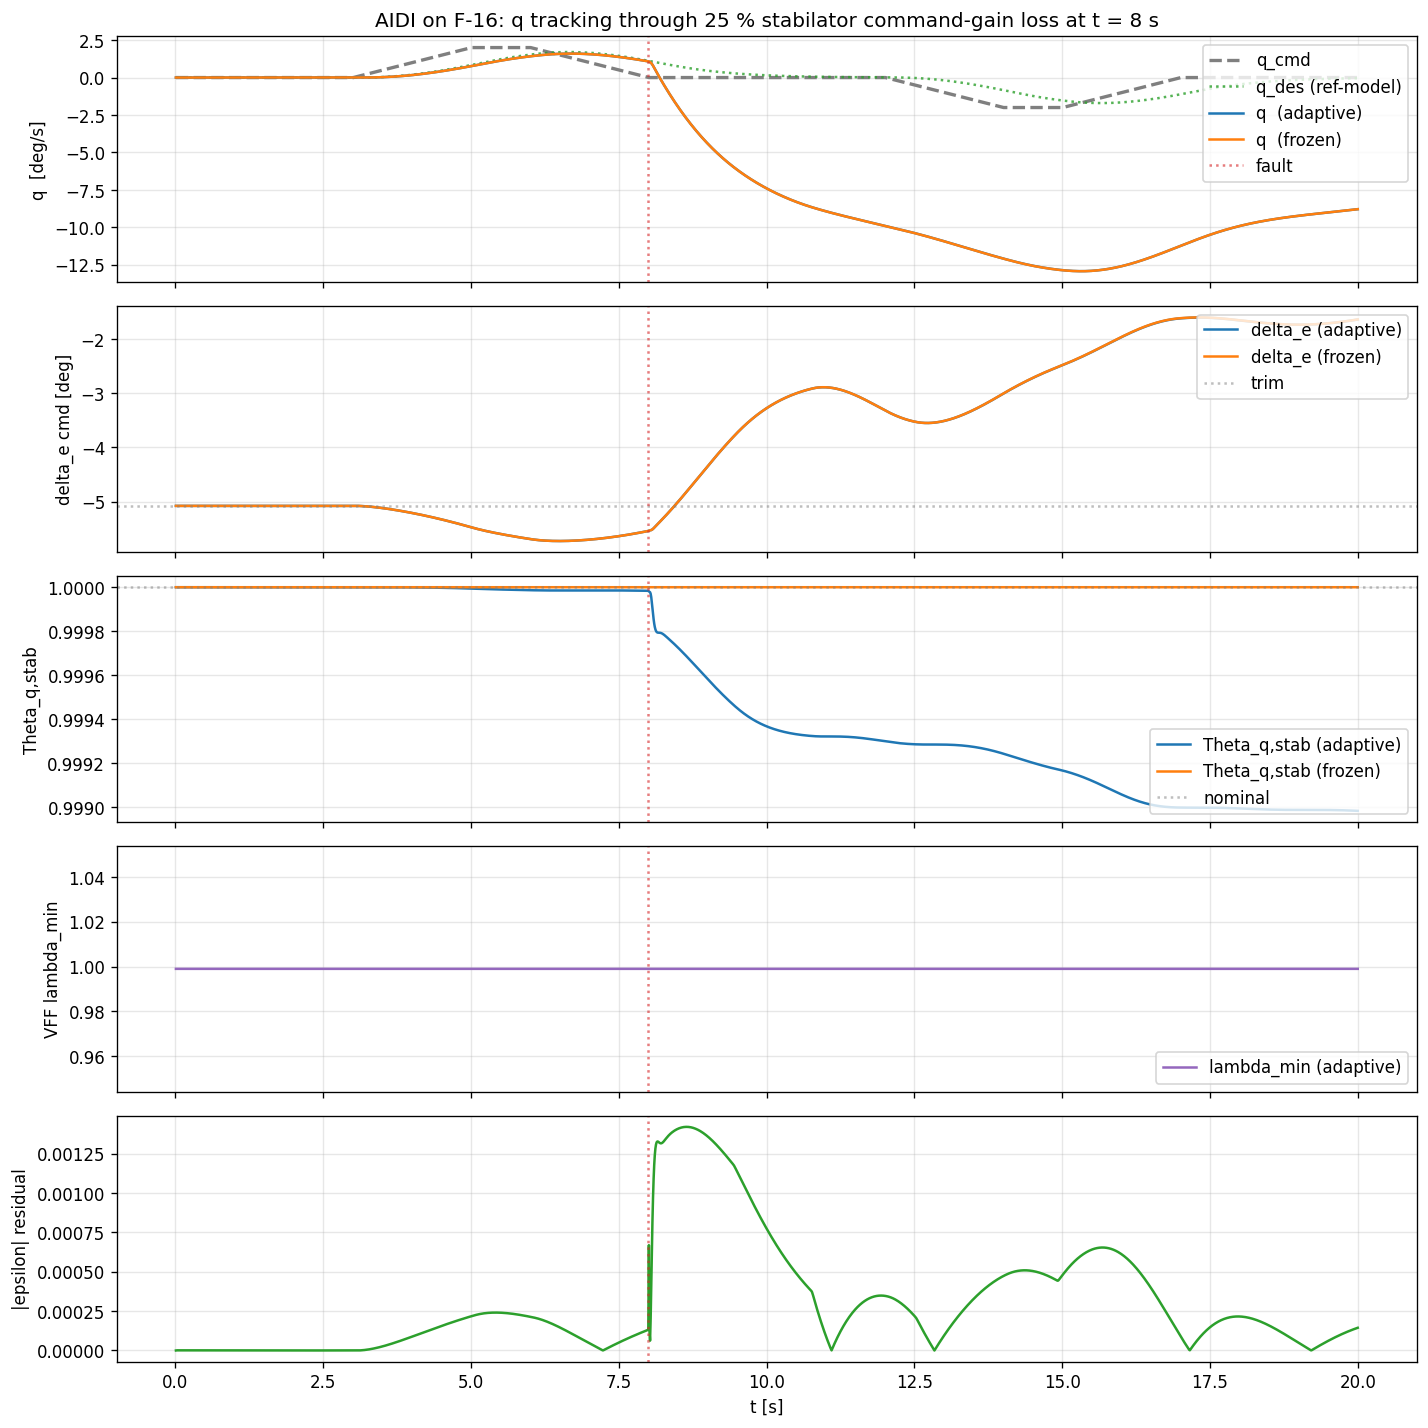

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

axes[0].plot(adaptive['t'], np.degrees(adaptive['q_cmd']), '--', color='tab:gray',
             label='q_cmd', linewidth=2)
axes[0].plot(adaptive['t'], np.degrees(adaptive['q_des']), ':', color='tab:green',
             label='q_des (ref-model)', linewidth=1.5, alpha=0.8)
axes[0].plot(adaptive['t'], np.degrees(adaptive['q']), color='tab:blue',
             label='q  (adaptive)')
axes[0].plot(frozen  ['t'], np.degrees(frozen  ['q']), color='tab:orange',
             label='q  (frozen)')
axes[0].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6, label='fault')
axes[0].set_ylabel('q  [deg/s]'); axes[0].grid(alpha=0.3); axes[0].legend(loc='upper right')
axes[0].set_title('AIDI on F-16: q tracking through 25 % stabilator command-gain loss at t = 8 s')

axes[1].plot(adaptive['t'], adaptive['stab'], color='tab:blue',   label='delta_e (adaptive)')
axes[1].plot(frozen  ['t'], frozen  ['stab'], color='tab:orange', label='delta_e (frozen)')
axes[1].axhline(math.degrees(stab_trim_rad), color='tab:gray', linestyle=':', alpha=0.5, label='trim')
axes[1].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[1].set_ylabel('delta_e cmd [deg]'); axes[1].grid(alpha=0.3); axes[1].legend(loc='upper right')

axes[2].plot(adaptive['t'], adaptive['theta_q_stab'], color='tab:blue', label='Theta_q,stab (adaptive)')
axes[2].plot(frozen  ['t'], frozen  ['theta_q_stab'], color='tab:orange', label='Theta_q,stab (frozen)')
axes[2].axhline(1.0, color='tab:gray', linestyle=':', alpha=0.5, label='nominal')
axes[2].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[2].set_ylabel('Theta_q,stab'); axes[2].grid(alpha=0.3); axes[2].legend(loc='lower right')

axes[3].plot(adaptive['t'], adaptive['lambda_min'], color='tab:purple', label='lambda_min (adaptive)')
axes[3].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[3].set_ylabel('VFF lambda_min'); axes[3].grid(alpha=0.3); axes[3].legend(loc='lower right')

axes[4].plot(adaptive['t'], adaptive['residual'], color='tab:green', label='|epsilon|')
axes[4].axvline(FAULT_TIME, color='tab:red', linestyle=':', alpha=0.6)
axes[4].set_ylabel('|epsilon| residual'); axes[4].set_xlabel('t [s]'); axes[4].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 7. Interpretation

Read the printed RMSE values and trajectories together. This experiment tests pitch-rate tracking for 20 seconds, with continuously running identification and measured actuator feedback. It is not a demonstration of full-flight stability or guaranteed superiority of adaptation.

The fault leaves 75% of the commanded stabilator deflection. It does not multiply the moment generated by an already achieved deflection, so the fitted `Theta` is not expected to approach 0.25. Remaining actuator authority and excitation affect both controllers.

For additional body-rate checks, use the public `python -m tensoraerospace.scripts.benchmark_aidi` CLI described in the [AIDI documentation](../../../docs/en/agent/aidi.md). Extend the simulation horizon and inspect aircraft attitudes as well as tracking error. The fixed baseline is solely a diagnostic; the adaptive controller never receives the fault time.
